In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("combined_dataset.csv")
df.head(5)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
print(df['Label'].value_counts())

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


### Drop NUN and INF

In [4]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"NaNs drop: {df.isna().sum().sum()}")
df.dropna(inplace=True)
print(f"Shape after dropping: {df.shape}")

NaNs drop: 5734
Shape after dropping: (2827876, 79)


In [5]:
df.columns = df.columns.str.strip() # strip right spaces in column names
print(df.columns)

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

#### drop columns that unique to specific attack

In [6]:
drop_cols = [
    "Destination Port", 
    "Fwd Header Length.1", 
    "Init_Win_bytes_forward", 
    "Init_Win_bytes_backward"
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
print(df.columns)
print(df.shape)

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Flag Count', 'PS

In [8]:
label_col = "Label"
y = df[label_col].copy()
X = df.drop(columns=[label_col])
 
X = X.select_dtypes(include=[np.number])
 
y_binary = (y != "BENIGN").astype(int)
 
print(f"Feature shape: {X.shape}")
print(y.value_counts())
print(y_binary.value_counts())

Feature shape: (2827876, 74)
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
Label
0    2271320
1     556556
Name: count, dtype: int64


In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [13]:
X_benign = X[y_binary == 0]
X_attack = X[y_binary == 1]
y_attack_labels = y[y_binary == 1]
 
# Split benign into train/test
X_benign_train, X_benign_test = train_test_split(
    X_benign, test_size=0.3, random_state=42, stratify=y_binary[y_binary == 0]
)
 
# Test set = held-out benign + all attack samples
X_test = pd.concat([X_benign_test, X_attack])
y_test = pd.concat([
    pd.Series(np.zeros(len(X_benign_test)), index=X_benign_test.index),
    pd.Series(np.ones(len(X_attack)), index=X_attack.index)
])

In [14]:
print(f"Train (benign only): {X_benign_train.shape}")
print(f"Test (benign+attack): {X_test.shape}, attack ratio: {y_test.mean():.4f}")

Train (benign only): (1589924, 74)
Test (benign+attack): (1237952, 74), attack ratio: 0.4496


In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_benign_train)
X_test_scaled = scaler.transform(X_test)
 
iso_forest = IsolationForest(
    n_estimators=200,       # number of trees; more = more stable, slower
    max_samples="auto",     # subsample size per tree
    contamination=0.03,     # assume ~1% noise/mislabeled benign in training
    max_features=1.0,
    random_state=42,
    n_jobs=-1                # use all CPU cores
)
 
iso_forest.fit(X_train_scaled)
print("trained.")

trained.


In [ ]:
raw_scores = iso_forest.decision_function(X_test_scaled)
anomaly_scores = -raw_scores  
#y_pred = (iso_forest.predict(X_test_scaled) == -1).astype(int)

precisions_tmp, recalls_tmp, thresholds_tmp = precision_recall_curve(y_test, anomaly_scores)
TARGET_RECALL = 0.80  
valid_idx = np.where(recalls_tmp[:-1] >= TARGET_RECALL)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[np.argmax(precisions_tmp[valid_idx])]
    custom_threshold = thresholds_tmp[best_idx]
else:
    custom_threshold = np.median(anomaly_scores)
 
print(f"\nUsing custom threshold: {custom_threshold:.4f} "
      f"(chosen to hit >= {TARGET_RECALL*100:.0f}% recall)")
 
y_pred = (anomaly_scores >= custom_threshold).astype(int)
 

print("\n=== Classification Report (BENIGN vs ATTACK) ===")
print(classification_report(y_test, y_pred, target_names=["BENIGN", "ATTACK"]))
 
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)
 
# ROC-AUC and PR-AUC (better for imbalanced data than accuracy)
roc_auc = roc_auc_score(y_test, anomaly_scores)
pr_auc = average_precision_score(y_test, anomaly_scores)
print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")



Using custom threshold: -0.2465 (chosen to hit >= 80% recall)

=== Classification Report (BENIGN vs ATTACK) ===
              precision    recall  f1-score   support

      BENIGN       0.88      0.45      0.60    681396
      ATTACK       0.58      0.92      0.71    556556

    accuracy                           0.66   1237952
   macro avg       0.73      0.69      0.65   1237952
weighted avg       0.74      0.66      0.65   1237952


=== Confusion Matrix ===
[[307195 374201]
 [ 42948 513608]]

ROC-AUC: 0.7370
PR-AUC:  0.7015



=== Detection Rate by Attack Type ===
true_label
Heartbleed                    1.000000
Infiltration                  0.444444
DoS Hulk                      0.215036
DoS slowloris                 0.179434
DDoS                          0.043382
DoS Slowhttptest              0.039462
Web Attack � XSS              0.018405
BENIGN                        0.010230
DoS GoldenEye                 0.000097
PortScan                      0.000088
Bot                           0.000000
FTP-Patator                   0.000000
SSH-Patator                   0.000000
Web Attack � Brute Force      0.000000
Web Attack � Sql Injection    0.000000
Name: predicted_anomaly, dtype: float64

Saved plot to isolation_forest_results.png

Threshold for >=90% recall: -0.3333 (precision=0.4496)


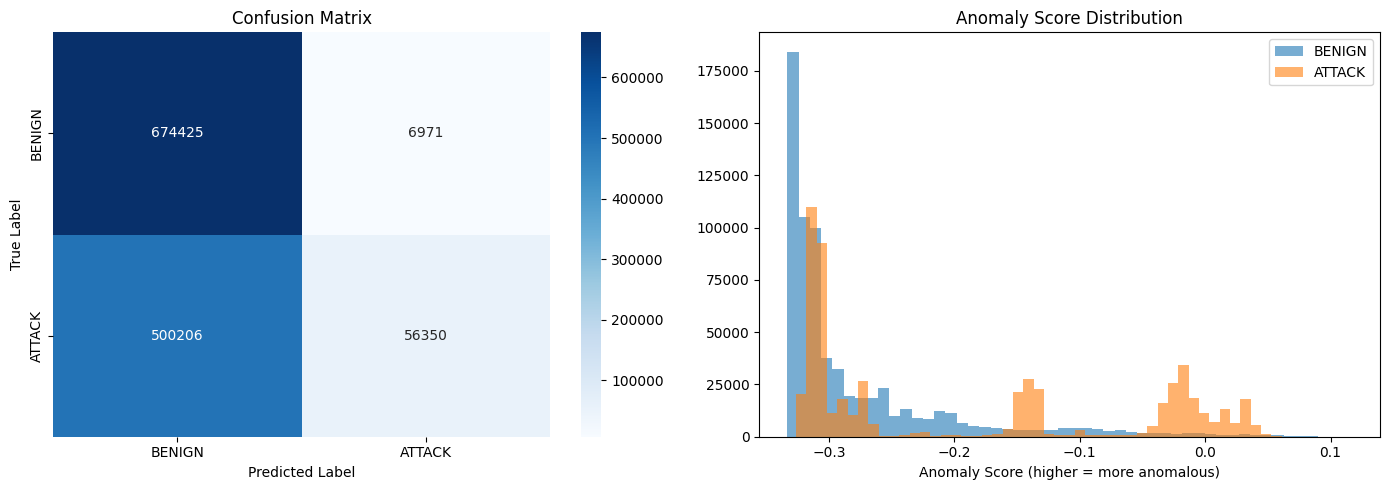

In [ ]:
results_df = pd.DataFrame({
    "true_label": y.loc[X_test.index],
    "predicted_anomaly": y_pred
}, index=X_test.index)
 
print("\n=== Detection Rate by Attack Type ===")
detection_rate = results_df.groupby("true_label")["predicted_anomaly"].mean().sort_values(ascending=False)
print(detection_rate)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["BENIGN", "ATTACK"], yticklabels=["BENIGN", "ATTACK"],
            ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")
 
axes[1].hist(anomaly_scores[y_test == 0], bins=50, alpha=0.6, label="BENIGN")
axes[1].hist(anomaly_scores[y_test == 1], bins=50, alpha=0.6, label="ATTACK")
axes[1].set_title("Anomaly Score Distribution")
axes[1].set_xlabel("Anomaly Score (higher = more anomalous)")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("isolation_forest_results.png", dpi=150)
print("\nSaved plot to isolation_forest_results.png")
precisions, recalls, thresholds = precision_recall_curve(y_test, anomaly_scores)
# Example: find threshold that gives at least 90% recall
target_recall = 0.90
idx = np.argmax(recalls >= target_recall) if np.any(recalls >= target_recall) else -1
if idx != -1 and idx < len(thresholds):
    print(f"\nThreshold for >={target_recall*100:.0f}% recall: {thresholds[idx]:.4f} "
          f"(precision={precisions[idx]:.4f})")
 